# Лаба 7

## Данные

я хочу, чтобы моя лабораторная была не привязана к конкретной валюте

так как иначе если я опять ошибусь в цифрах для своего варианта, то придется исправлять

https://docs.google.com/spreadsheets/d/1-r6yMj-ZMqJ05YRM2xBgLqRL62it-B2zdz2bay-Osc4/edit?usp=sharing

In [18]:
import pandas as pd

data = {
    'Период': [
        'Янв 22', 'Фев 22', 'Мар 22', 'Апр 22', 'Май 22', 'Июн 22', 'Июл 22', 'Авг 22', 'Сен 22', 'Окт 22', 'Ноя 22', 'Дек 22',
        'Янв 23', 'Фев 23', 'Мар 23', 'Апр 23', 'Май 23', 'Июн 23', 'Июл 23', 'Авг 23', 'Сен 23', 'Окт 23', 'Ноя 23', 'Дек 23',
        'Янв 24', 'Фев 24', 'Мар 24', 'Апр 24', 'Май 24', 'Июн 24', 'Июл 24'
    ],
    'Курс_X': [
        9.3319, 9.1344, 10.2309, 9.9685, 8.7716, 8.7210, 8.6923, 7.1413, 6.9189, 6.7488, 6.7063, 6.5873,
        7.4457, 7.2783, 7.5860, 7.7741, 7.9219, 7.9075, 8.2084, 8.2163, 8.7435, 8.8694, 8.7068, 8.5345,
        8.4558, 8.4152, 8.4448, 8.2823, 8.2081, 7.8807, 7.8140
    ],
    'Зарплата_Y': [
        1477.8, 1563.0, 1602.7, 1567.8, 1573.4, 1626.5, 1471.7, 1463.2, 1637.0, 1636.4, 1648.2, 1915.6,
        1684.9, 1687.8, 1814.2, 1795.9, 1861.1, 1927.1, 1644.0, 1665.5, 1939.8, 1971.2, 1975.6, 2246.8,
        2005.6, 2025.7, 2161.1, 2182.5, 2219.2, 2270.0, 2355.1
    ]
}

df = pd.DataFrame(data)

print("Данные успешно загружены:", df.shape)
print(df.head())

Данные успешно загружены: (31, 3)
   Период   Курс_X  Зарплата_Y
0  Янв 22   9.3319      1477.8
1  Фев 22   9.1344      1563.0
2  Мар 22  10.2309      1602.7
3  Апр 22   9.9685      1567.8
4  Май 22   8.7716      1573.4


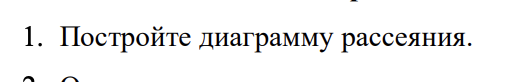

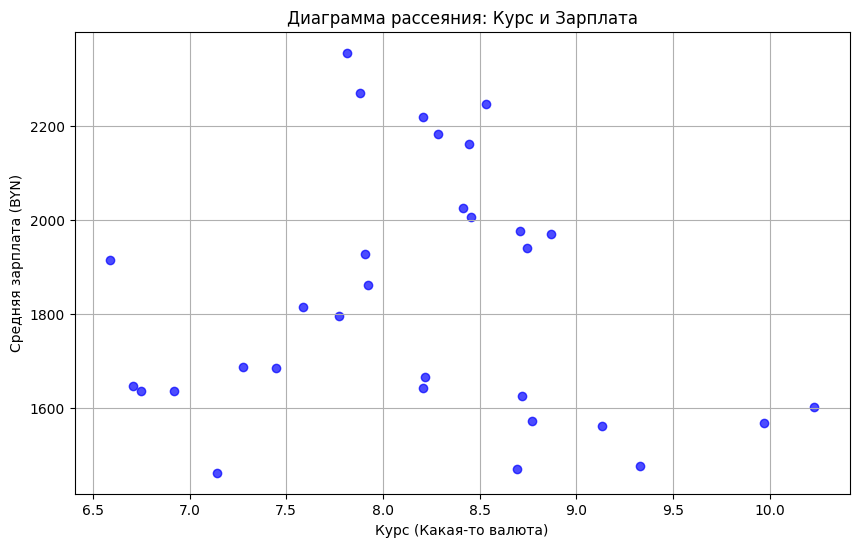

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(df['Курс_X'], df['Зарплата_Y'], color='blue', alpha=0.7)
plt.title('Диаграмма рассеяния: Курс и Зарплата')
plt.xlabel('Курс (Какая-то валюта)')
plt.ylabel('Средняя зарплата (BYN)')
plt.grid(True)
plt.show()

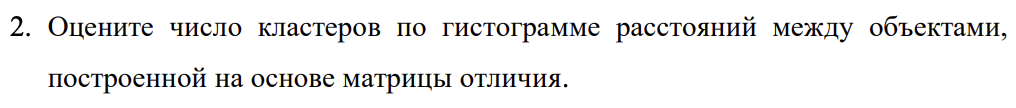

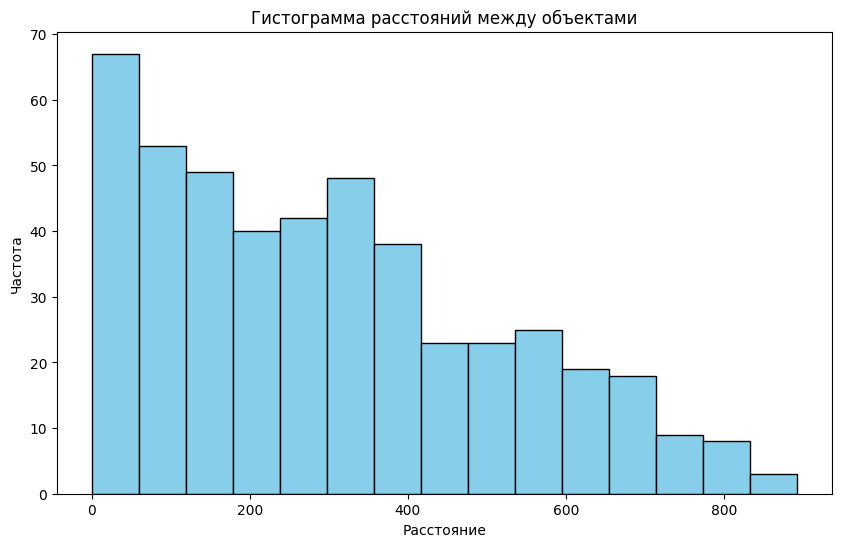

In [ ]:
from scipy.spatial.distance import pdist
import numpy as np

# Вычисляем евклидовы расстояния между всеми точками (X и Y)
coords = df[['Курс_X', 'Зарплата_Y']].values
distances = pdist(coords, metric='euclidean')

plt.figure(figsize=(10, 6))
plt.hist(distances, bins=15, color='skyblue', edgecolor='black')
plt.title('Гистограмма расстояний между объектами')
plt.xlabel('Расстояние')
plt.ylabel('Частота')
plt.show()

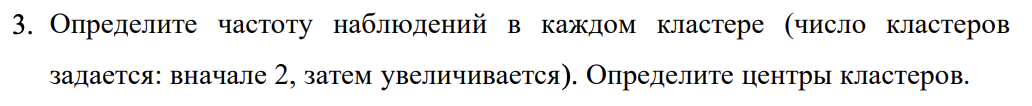

https://github.com/scikit-learn/scikit-learn/blob/main/sklearn/cluster/_kmeans.py



In [25]:
from sklearn.cluster import KMeans

kmeans2 = KMeans(n_clusters=2, random_state=42, n_init=10).fit(coords)
df['Кластер_2'] = kmeans2.labels_

print("--- k=2 ---")
print("Частота")
print(df['Кластер_2'].value_counts())
print("\nЦентры (Курс, Зарплата):")
print(kmeans2.cluster_centers_)

kmeans3 = KMeans(n_clusters=3, random_state=42, n_init=10).fit(coords)
df['Кластер_3'] = kmeans3.labels_

print("\n--- k=3 ---")
print("Частота наблюдений в кластерах:")
print(df['Кластер_3'].value_counts())
print("\nЦентры (Курс, Зарплата):")
print(kmeans3.cluster_centers_)

kmeans4 = KMeans(n_clusters=4, random_state=42, n_init=10).fit(coords)
df['Кластер_4'] = kmeans4.labels_

print("\n--- k=4 ---")
print("Частота наблюдений в кластерах:")
print(df['Кластер_4'].value_counts())
print("\nЦентры (Курс, Зарплата):")
print(kmeans4.cluster_centers_)

--- k=2 ---
Частота
Кластер_2
0    17
1    14
Name: count, dtype: int64

Центры (Курс, Зарплата):
[[   8.1691     1621.17647059]
 [   8.19798571 2075.45714286]]

--- k=3 ---
Частота наблюдений в кластерах:
Кластер_3
1    15
2    10
0     6
Name: count, dtype: int64

Центры (Курс, Зарплата):
[[   8.19406667 2239.11666667]
 [   8.23430667 1596.66      ]
 [   8.09675    1923.18      ]]

--- k=4 ---
Частота наблюдений в кластерах:
Кластер_4
2    10
3     9
0     6
1     6
Name: count, dtype: int64

Центры (Курс, Зарплата):
[[   8.84       1519.48333333]
 [   8.19406667 2239.11666667]
 [   8.09675    1923.18      ]
 [   7.83051111 1648.11111111]]


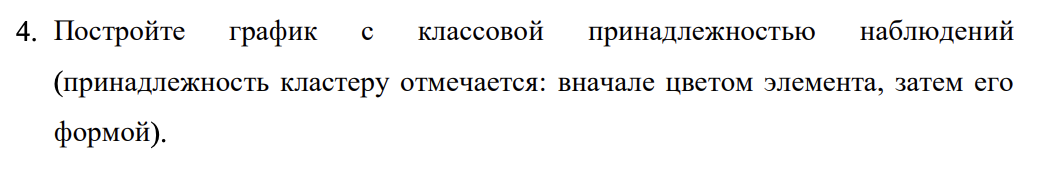

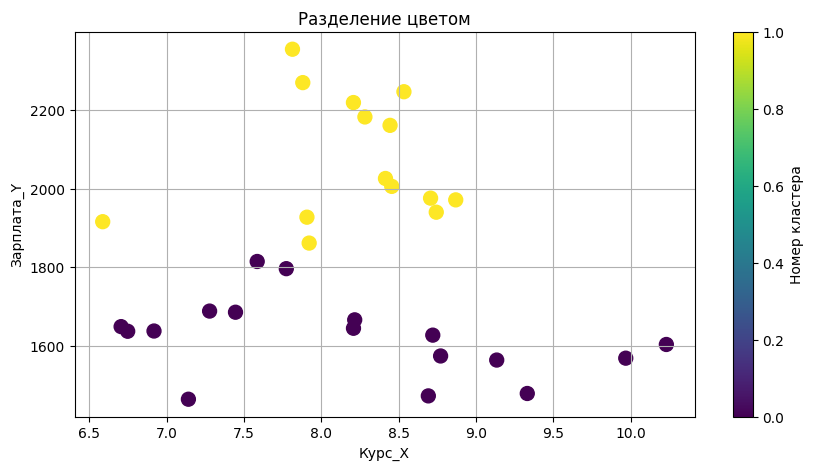

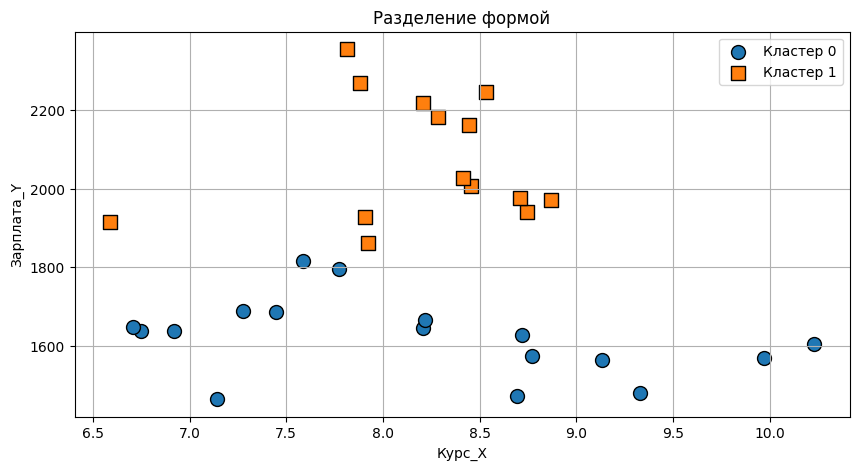

In [23]:
plt.figure(figsize=(10, 5))
plt.scatter(df['Курс_X'], df['Зарплата_Y'], c=df['Кластер_2'], cmap='viridis', s=100)
plt.title('Разделение цветом')
plt.xlabel('Курс_X')
plt.ylabel('Зарплата_Y')
plt.colorbar(label='Номер кластера')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
markers = ['o', 's', '^'] # круг, квадрат, треугольник
for i in range(2):
    cluster_data = df[df['Кластер_2'] == i]
    plt.scatter(cluster_data['Курс_X'], cluster_data['Зарплата_Y'], 
                marker=markers[i], label=f'Кластер {i}', s=100, edgecolors='black')

plt.title('Разделение формой')
plt.xlabel('Курс_X')
plt.ylabel('Зарплата_Y')
plt.legend()
plt.grid(True)
plt.show()

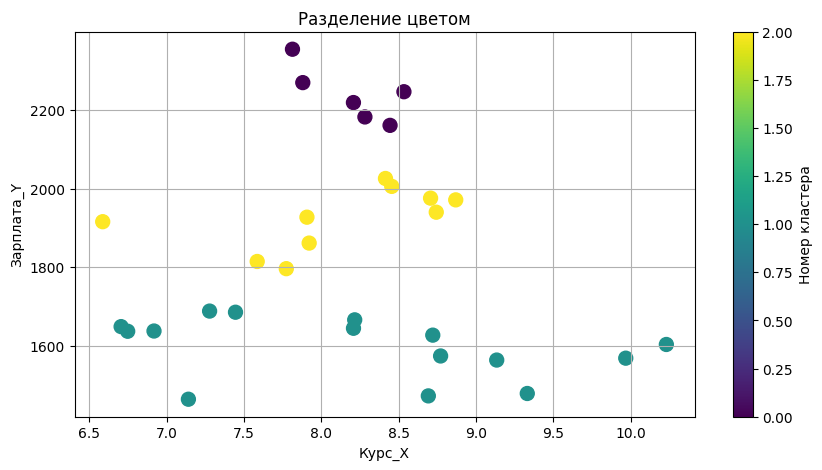

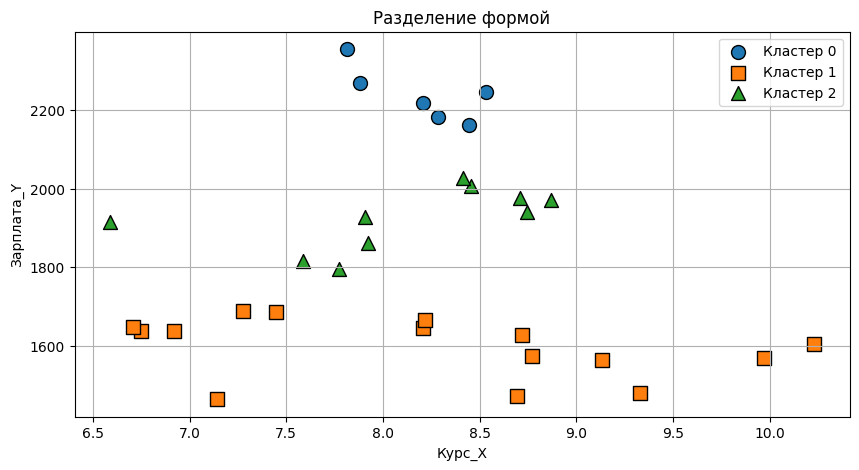

In [24]:
plt.figure(figsize=(10, 5))
plt.scatter(df['Курс_X'], df['Зарплата_Y'], c=df['Кластер_3'], cmap='viridis', s=100)
plt.title('Разделение цветом')
plt.xlabel('Курс_X')
plt.ylabel('Зарплата_Y')
plt.colorbar(label='Номер кластера')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
markers = ['o', 's', '^'] # круг, квадрат, треугольник
for i in range(3):
    cluster_data = df[df['Кластер_3'] == i]
    plt.scatter(cluster_data['Курс_X'], cluster_data['Зарплата_Y'], 
                marker=markers[i], label=f'Кластер {i}', s=100, edgecolors='black')

plt.title('Разделение формой')
plt.xlabel('Курс_X')
plt.ylabel('Зарплата_Y')
plt.legend()
plt.grid(True)
plt.show()

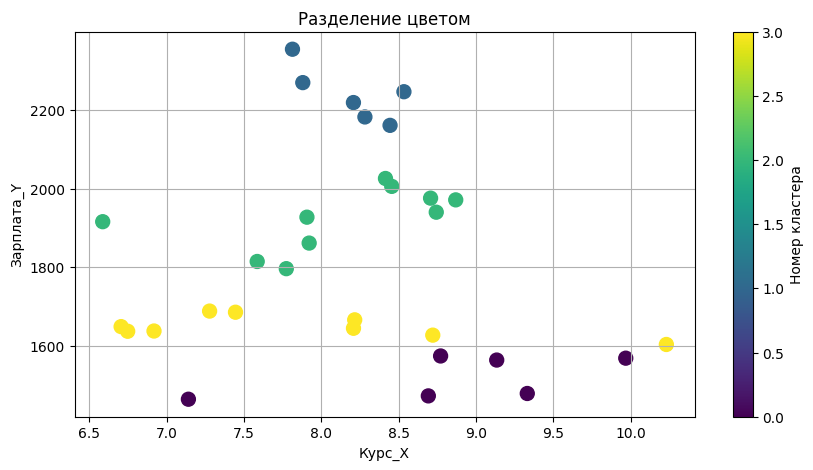

ValueError: Unrecognized marker style 'a'

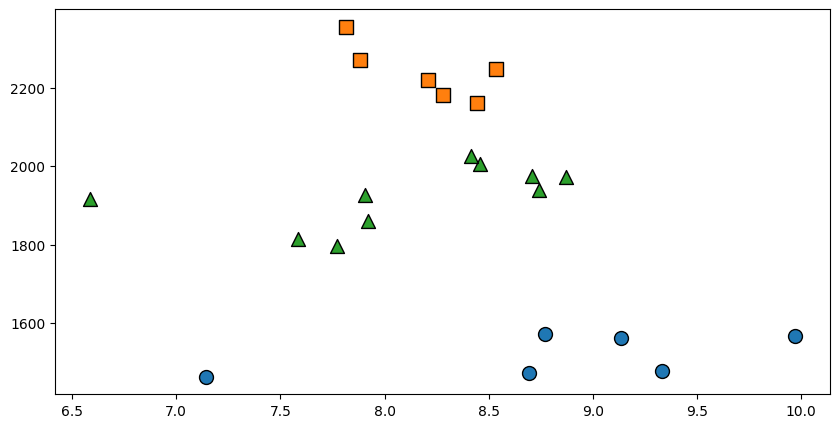

In [27]:
plt.figure(figsize=(10, 5))
plt.scatter(df['Курс_X'], df['Зарплата_Y'], c=df['Кластер_4'], cmap='viridis', s=100)
plt.title('Разделение цветом')
plt.xlabel('Курс_X')
plt.ylabel('Зарплата_Y')
plt.colorbar(label='Номер кластера')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
markers = ['o', 's', '^', 'a'] # круг, квадрат, треугольник
for i in range(4):
    cluster_data = df[df['Кластер_4'] == i]
    plt.scatter(cluster_data['Курс_X'], cluster_data['Зарплата_Y'], 
                marker=markers[i], label=f'Кластер {i}', s=100, edgecolors='black')

plt.title('Разделение формой')
plt.xlabel('Курс_X')
plt.ylabel('Зарплата_Y')
plt.legend()
plt.grid(True)
plt.show()